In [1]:
import json
from pathlib import Path
from itertools import product
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath("../"))
from simulators.drossel_schwabl_CA import DrosselSchwablForestFire
from simulators.CA_modified import CellularAutomaton_humidity_age
from simulators.metrics import FireMetrics

In [2]:
DATASET_DIR = Path("synthetic_fire_dataset")

env = np.load(DATASET_DIR / "common_maps.npz")
height_grid = env["height_grid"]
age_grid = env["age_grid"]
moisture_grid = env["moisture_grid"]

with open(DATASET_DIR / "dataset_index.json", "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

print("Nombre de feux :", len(dataset_index))
print("Shape :", height_grid.shape)

with open(DATASET_DIR / "config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

N_STEPS = config["N_STEPS"]
print("N_STEPS used for evaluation:", N_STEPS)

Nombre de feux : 20
Shape : (100, 100)
N_STEPS used for evaluation: 20


In [3]:
def make_phi(gamma):
    def phi(delta_h):
        if delta_h <= 0:
            return np.exp(gamma * delta_h)
        else:
            return 1.0 + gamma * np.sqrt(delta_h)
    return phi

def make_psi(beta):
    def psi(m):
        return np.exp(-beta * m)
    return psi

In [4]:
def initialize_center_pixel(ca, value=1.0):
    H, W = ca.get_state().shape
    ca.initialize_ignition([(H // 2, W // 2)], [value])

In [5]:
def simulate_fire_candidate(
    height_grid,
    age_grid,
    moisture_grid,
    wind_grid,
    alpha,
    beta,
    gamma,
    n_steps=150,
):
    H, W = height_grid.shape

    ca = CellularAutomaton_humidity_age(
        grid_height=H,
        grid_width=W,
        wind_grid=wind_grid,
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        phi=make_phi(gamma),
        psi=make_psi(beta),
        alpha_age=alpha,
    )

    ca.initialize_ignition([(H // 2, W // 2)], [0.8])

    arrival_time = -np.ones((H, W), dtype=np.int16)
    state0 = ca.get_state().copy()
    arrival_time[state0 >= 0.5] = 0

    for step in range(n_steps):
        ca.evolve(use_age=True, use_moisture=True)

        state = ca.get_state().copy()
        new_cells = (state >= 0.5) & (arrival_time < 0)
        arrival_time[new_cells] = step + 1

    return {
        "final_state": ca.get_state().copy().astype(np.float32),
        "arrival_time": arrival_time,
    }

In [6]:
def iou_score(pred, obs, tau=0.5):
    pred_bin = pred >= tau
    obs_bin = obs >= tau

    inter = np.logical_and(pred_bin, obs_bin).sum()
    union = np.logical_or(pred_bin, obs_bin).sum()

    if union == 0:
        return 1.0
    return inter / union

In [7]:
def evaluate_one_fire_metrics(
    fire_path,
    height_grid,
    age_grid,
    moisture_grid,
    alpha,
    beta,
    gamma,
    n_steps=N_STEPS,
    tau=0.5,
):
    obs = np.load(fire_path)

    wind_grid = obs["wind_grid"].astype(np.float32)
    obs_final = obs["final_state"].astype(np.float32) / 255.0
    obs_arrival = obs["arrival_time"].astype(np.int16)

    pred = simulate_fire_candidate(
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        wind_grid=wind_grid,
        alpha=alpha,
        beta=beta,
        gamma=gamma,
        n_steps=n_steps,
    )

    pred_final = pred["final_state"]
    pred_arrival = pred["arrival_time"]

    iou = iou_score(pred_final, obs_final, tau=tau)
    aatd = FireMetrics.aatd_from_maps(pred_arrival, obs_arrival)

    return {
        "iou": float(iou),
        "iou_loss": float(1.0 - iou),
        "aatd": float(aatd) if np.isfinite(aatd) else np.nan,
    }

In [8]:
def evaluate_params_metrics(
    fire_paths,
    height_grid,
    age_grid,
    moisture_grid,
    alpha,
    beta,
    gamma,
    n_steps=N_STEPS,
    tau=0.5,
):
    scores = []

    for fire_path in fire_paths:
        s = evaluate_one_fire_metrics(
            fire_path=fire_path,
            height_grid=height_grid,
            age_grid=age_grid,
            moisture_grid=moisture_grid,
            alpha=alpha,
            beta=beta,
            gamma=gamma,
            n_steps=n_steps,
            tau=tau,
        )
        scores.append(s)

    mean_iou = float(np.mean([s["iou"] for s in scores]))
    mean_iou_loss = float(np.mean([s["iou_loss"] for s in scores]))

    valid_aatd = [s["aatd"] for s in scores if np.isfinite(s["aatd"])]
    mean_aatd = float(np.mean(valid_aatd)) if len(valid_aatd) > 0 else np.nan

    return {
        "alpha": alpha,
        "beta": beta,
        "gamma": gamma,
        "mean_iou": mean_iou,
        "mean_iou_loss": mean_iou_loss,
        "mean_aatd": mean_aatd,
    }

In [9]:
alpha_grid = [0.8, 2.0, 4.0]
beta_grid  = [0.5, 2.0, 5.0]
gamma_grid = [0.4, 1.2, 3.0]

N_EVAL_FIRES = 10

fire_paths = [
    DATASET_DIR / item["file"]
    for item in dataset_index[:N_EVAL_FIRES]
]

print("Nombre de triplets testés :", len(alpha_grid) * len(beta_grid) * len(gamma_grid))
print("Nombre de feux utilisés :", len(fire_paths))

Nombre de triplets testés : 27
Nombre de feux utilisés : 10


In [10]:
results = []

for alpha, beta, gamma in product(alpha_grid, beta_grid, gamma_grid):
    print(f"Test alpha={alpha}, beta={beta}, gamma={gamma}")

    row = evaluate_params_metrics(
        fire_paths=fire_paths,
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        alpha=alpha,
        beta=beta,
        gamma=gamma,
        n_steps=N_STEPS,
        tau=0.5,
    )

    results.append(row)

results_df = pd.DataFrame(results)

Test alpha=0.8, beta=0.5, gamma=0.4
Test alpha=0.8, beta=0.5, gamma=1.2
Test alpha=0.8, beta=0.5, gamma=3.0
Test alpha=0.8, beta=2.0, gamma=0.4
Test alpha=0.8, beta=2.0, gamma=1.2
Test alpha=0.8, beta=2.0, gamma=3.0
Test alpha=0.8, beta=5.0, gamma=0.4
Test alpha=0.8, beta=5.0, gamma=1.2
Test alpha=0.8, beta=5.0, gamma=3.0
Test alpha=2.0, beta=0.5, gamma=0.4
Test alpha=2.0, beta=0.5, gamma=1.2
Test alpha=2.0, beta=0.5, gamma=3.0
Test alpha=2.0, beta=2.0, gamma=0.4
Test alpha=2.0, beta=2.0, gamma=1.2
Test alpha=2.0, beta=2.0, gamma=3.0
Test alpha=2.0, beta=5.0, gamma=0.4
Test alpha=2.0, beta=5.0, gamma=1.2
Test alpha=2.0, beta=5.0, gamma=3.0
Test alpha=4.0, beta=0.5, gamma=0.4
Test alpha=4.0, beta=0.5, gamma=1.2
Test alpha=4.0, beta=0.5, gamma=3.0
Test alpha=4.0, beta=2.0, gamma=0.4
Test alpha=4.0, beta=2.0, gamma=1.2
Test alpha=4.0, beta=2.0, gamma=3.0
Test alpha=4.0, beta=5.0, gamma=0.4
Test alpha=4.0, beta=5.0, gamma=1.2
Test alpha=4.0, beta=5.0, gamma=3.0


In [11]:
df = results_df.copy()
results_df.sort_values("mean_iou_loss").head(10)

best = results_df.sort_values("mean_iou_loss").iloc[0]

print("Meilleurs paramètres trouvés :")
print(best[["alpha", "beta", "gamma", "mean_iou", "mean_iou_loss"]])

Meilleurs paramètres trouvés :
alpha            2.00000
beta             2.00000
gamma            1.20000
mean_iou         0.99959
mean_iou_loss    0.00041
Name: 13, dtype: float64


In [12]:
print(results_df.sort_values("mean_iou_loss"))

    alpha  beta  gamma  mean_iou  mean_iou_loss  mean_aatd
13    2.0   2.0    1.2  0.999590       0.000410   0.000000
12    2.0   2.0    0.4  0.971297       0.028703   0.220477
4     0.8   2.0    1.2  0.953573       0.046427   0.223434
14    2.0   2.0    3.0  0.949246       0.050754   0.397051
22    4.0   2.0    1.2  0.947790       0.052210   0.266030
3     0.8   2.0    0.4  0.938066       0.061934   0.352531
23    4.0   2.0    3.0  0.920666       0.079334   0.507695
21    4.0   2.0    0.4  0.918583       0.081417   0.500291
5     0.8   2.0    3.0  0.907586       0.092414   0.602127
18    4.0   0.5    0.4  0.779457       0.220543   1.955380
19    4.0   0.5    1.2  0.774564       0.225436   2.018308
20    4.0   0.5    3.0  0.766883       0.233117   2.125395
9     2.0   0.5    0.4  0.729784       0.270216   2.167637
10    2.0   0.5    1.2  0.724245       0.275755   2.225563
11    2.0   0.5    3.0  0.716787       0.283213   2.319290
0     0.8   0.5    0.4  0.691706       0.308294   2.2511

In [13]:
results_df.sort_values("mean_aatd").head(10)

,alpha,beta,gamma,mean_iou,mean_iou_loss,mean_aatd
13,2.0,2.0,1.2,0.999590,0.000410,0.000000
12,2.0,2.0,0.4,0.971297,0.028703,0.220477
4,0.8,2.0,1.2,0.953573,0.046427,0.223434
22,4.0,2.0,1.2,0.947790,0.052210,0.266030
3,0.8,2.0,0.4,0.938066,0.061934,0.352531
14,2.0,2.0,3.0,0.949246,0.050754,0.397051
21,4.0,2.0,0.4,0.918583,0.081417,0.500291
23,4.0,2.0,3.0,0.920666,0.079334,0.507695
5,0.8,2.0,3.0,0.907586,0.092414,0.602127
18,4.0,0.5,0.4,0.779457,0.220543,1.955380


Test on the grund truth

In [17]:
def simulate_fire_candidate_with_trajectory(
    height_grid,
    age_grid,
    moisture_grid,
    wind_grid,
    alpha,
    beta,
    gamma,
    n_steps=150,
    save_steps=None,
):
    H, W = height_grid.shape

    ca = CellularAutomaton_humidity_age(
        grid_height=H,
        grid_width=W,
        wind_grid=wind_grid,
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        phi=make_phi(gamma),
        psi=make_psi(beta),
        alpha_age=alpha,
    )

    # même ignition que dans la génération
    ca.initialize_ignition([(H // 2, W // 2)], [0.8])

    if save_steps is None:
        save_steps = [0, n_steps]
    save_steps = sorted(set(int(s) for s in save_steps))

    snapshots = {}
    arrival_time = -np.ones((H, W), dtype=np.int16)

    state = ca.get_state().copy()
    arrival_time[state >= 0.5] = 0

    if 0 in save_steps:
        snapshots[0] = state.copy().astype(np.float32)

    for step in range(1, n_steps + 1):
        ca.evolve(use_age=True, use_moisture=True)
        state = ca.get_state().copy()

        new_cells = (state >= 0.5) & (arrival_time < 0)
        arrival_time[new_cells] = step

        if step in save_steps:
            snapshots[step] = state.copy().astype(np.float32)

    return {
        "snapshots": snapshots,
        "final_state": ca.get_state().copy().astype(np.float32),
        "arrival_time": arrival_time,
    }

Best parameters found:
alpha = 2.0, beta = 2.0, gamma = 1.2
mean_iou = 0.9996


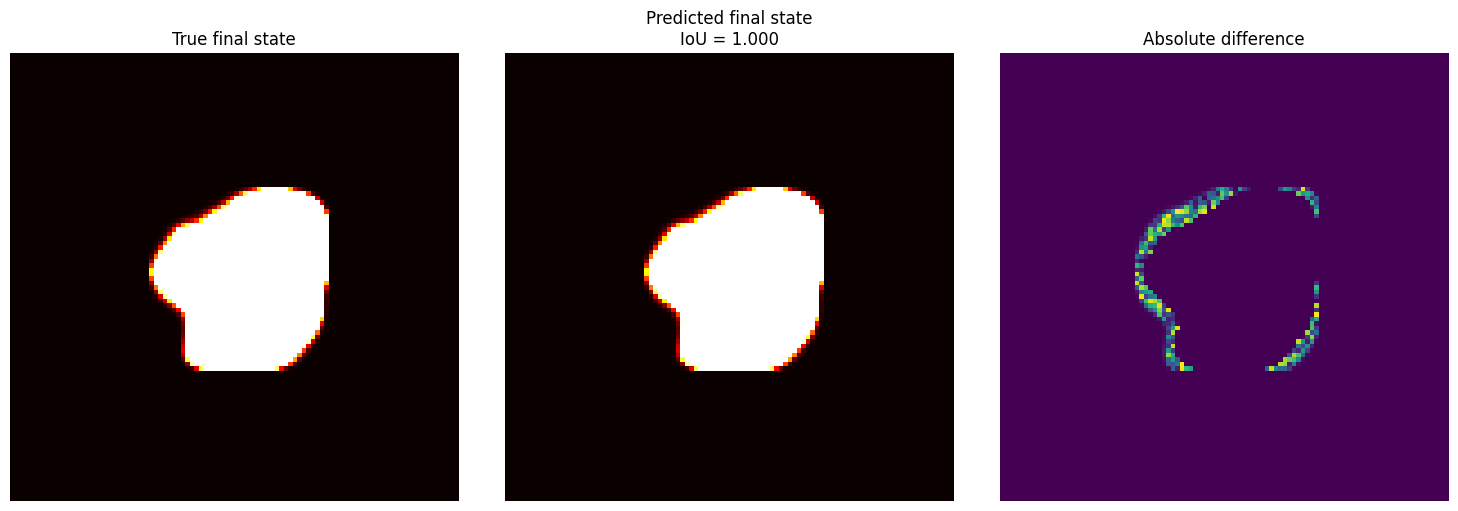

In [ ]:
best = results_df.sort_values("mean_iou_loss").iloc[0]
best_alpha = float(best["alpha"])
best_beta = float(best["beta"])
best_gamma = float(best["gamma"])

print("Best parameters found:")
print(f"alpha = {best_alpha}, beta = {best_beta}, gamma = {best_gamma}")
print(f"mean_iou = {best['mean_iou']:.4f}")

fire_path = fire_paths[0]
obs = np.load(fire_path)

wind_grid = obs["wind_grid"].astype(np.float32)
obs_final = obs["final_state"].astype(np.float32) / 255.0

pred = simulate_fire_candidate(
    height_grid=height_grid,
    age_grid=age_grid,
    moisture_grid=moisture_grid,
    wind_grid=wind_grid,
    alpha=best_alpha,
    beta=best_beta,
    gamma=best_gamma,
    n_steps=N_STEPS,
)

pred_final = pred["final_state"] if isinstance(pred, dict) else pred

iou = iou_score(pred_final, obs_final, tau=0.5)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(obs_final, cmap="hot")
axs[0].set_title("True final state")

axs[1].imshow(pred_final, cmap="hot")
axs[1].set_title(f"Predicted final state\nIoU = {iou:.3f}")

diff = np.abs(pred_final - obs_final)
axs[2].imshow(diff, cmap="viridis")
axs[2].set_title("Absolute difference")

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.show()


def get_best_params(results_df, criterion="mean_iou_loss"):
    best = results_df.sort_values(criterion).iloc[0]
    return float(best["alpha"]), float(best["beta"]), float(best["gamma"]), best







In [24]:
def plot_fire_comparison(
    fire_path,
    height_grid,
    age_grid,
    moisture_grid,
    alpha,
    beta,
    gamma,
    n_steps,
    step_indices=None,
):
    obs = np.load(fire_path)

    wind_grid = obs["wind_grid"].astype(np.float32)
    obs_saved_steps = obs["saved_steps"].astype(int)
    obs_snapshots = obs["snapshots"].astype(np.float32) / 255.0
    obs_final = obs["final_state"].astype(np.float32) / 255.0
    obs_arrival = obs["arrival_time"].astype(np.int16)

    if step_indices is None:
        idxs = np.unique(np.linspace(0, len(obs_saved_steps) - 1, 4, dtype=int))
    else:
        idxs = np.array(step_indices, dtype=int)

    selected_steps = obs_saved_steps[idxs].tolist()

    pred = simulate_fire_candidate_with_trajectory(
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        wind_grid=wind_grid,
        alpha=alpha,
        beta=beta,
        gamma=gamma,
        n_steps=n_steps,
        save_steps=selected_steps,
    )

    pred_snapshots = pred["snapshots"]
    pred_final = pred["final_state"]
    pred_arrival = pred["arrival_time"]

    n_time_cols = len(selected_steps)
    n_cols = n_time_cols + 2
    fig, axs = plt.subplots(3, n_cols, figsize=(3.3 * n_cols, 9))

    # Ligne 1 : ground truth
    for c, (idx, step) in enumerate(zip(idxs, selected_steps)):
        axs[0, c].imshow(obs_snapshots[idx], cmap="hot")
        axs[0, c].set_title(f"GT t={step}")
        axs[0, c].axis("off")

    axs[0, n_time_cols].imshow(obs_final, cmap="hot")
    axs[0, n_time_cols].set_title("GT final")
    axs[0, n_time_cols].axis("off")

    arr_gt_plot = np.where(obs_arrival >= 0, obs_arrival, np.nan)
    axs[0, n_time_cols + 1].imshow(arr_gt_plot, cmap="viridis")
    axs[0, n_time_cols + 1].set_title("GT arrival time")
    axs[0, n_time_cols + 1].axis("off")

    # Ligne 2 : prédiction
    for c, step in enumerate(selected_steps):
        axs[1, c].imshow(pred_snapshots[step], cmap="hot")
        axs[1, c].set_title(f"Pred t={step}")
        axs[1, c].axis("off")

    axs[1, n_time_cols].imshow(pred_final, cmap="hot")
    axs[1, n_time_cols].set_title("Pred final")
    axs[1, n_time_cols].axis("off")

    arr_pred_plot = np.where(pred_arrival >= 0, pred_arrival, np.nan)
    axs[1, n_time_cols + 1].imshow(arr_pred_plot, cmap="viridis")
    axs[1, n_time_cols + 1].set_title("Pred arrival time")
    axs[1, n_time_cols + 1].axis("off")

    # Ligne 3 : différences
    for c, (idx, step) in enumerate(zip(idxs, selected_steps)):
        diff_t = np.abs(pred_snapshots[step] - obs_snapshots[idx])
        axs[2, c].imshow(diff_t, cmap="magma")
        axs[2, c].set_title(f"|Diff| t={step}")
        axs[2, c].axis("off")

    final_diff = np.abs(pred_final - obs_final)
    final_iou = iou_score(pred_final, obs_final, tau=0.5)

    axs[2, n_time_cols].imshow(final_diff, cmap="magma")
    axs[2, n_time_cols].set_title(f"|Diff| final\nIoU={final_iou:.3f}")
    axs[2, n_time_cols].axis("off")

    arrival_diff = np.full_like(pred_arrival, np.nan, dtype=float)
    valid = (pred_arrival >= 0) & (obs_arrival >= 0)
    arrival_diff[valid] = np.abs(pred_arrival[valid] - obs_arrival[valid])

    aatd_val = FireMetrics.aatd_from_maps(pred_arrival, obs_arrival)

    axs[2, n_time_cols + 1].imshow(arrival_diff, cmap="magma")
    axs[2, n_time_cols + 1].set_title(f"|Arrival diff|\nAATD={aatd_val:.3f}")
    axs[2, n_time_cols + 1].axis("off")

    plt.suptitle(
        f"{fire_path.name} | alpha={alpha}, beta={beta}, gamma={gamma}",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

Best parameters according to AATD:
alpha        2.00000
beta         2.00000
gamma        1.20000
mean_iou     0.99959
mean_aatd    0.00000
Name: 13, dtype: float64


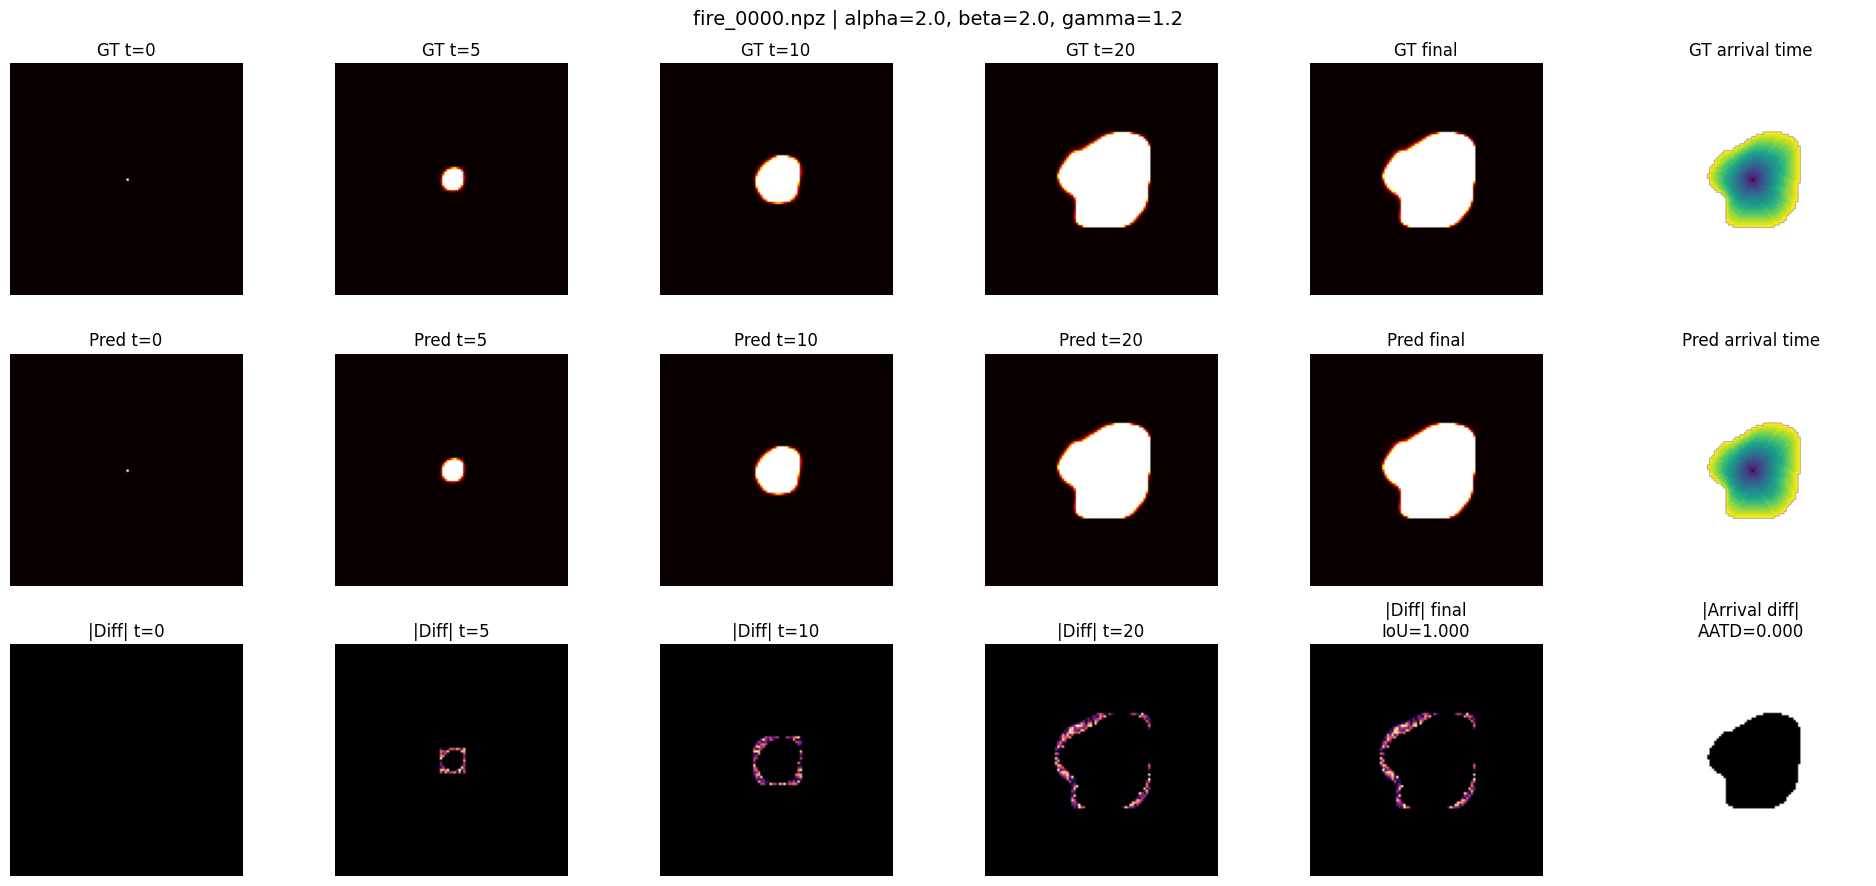

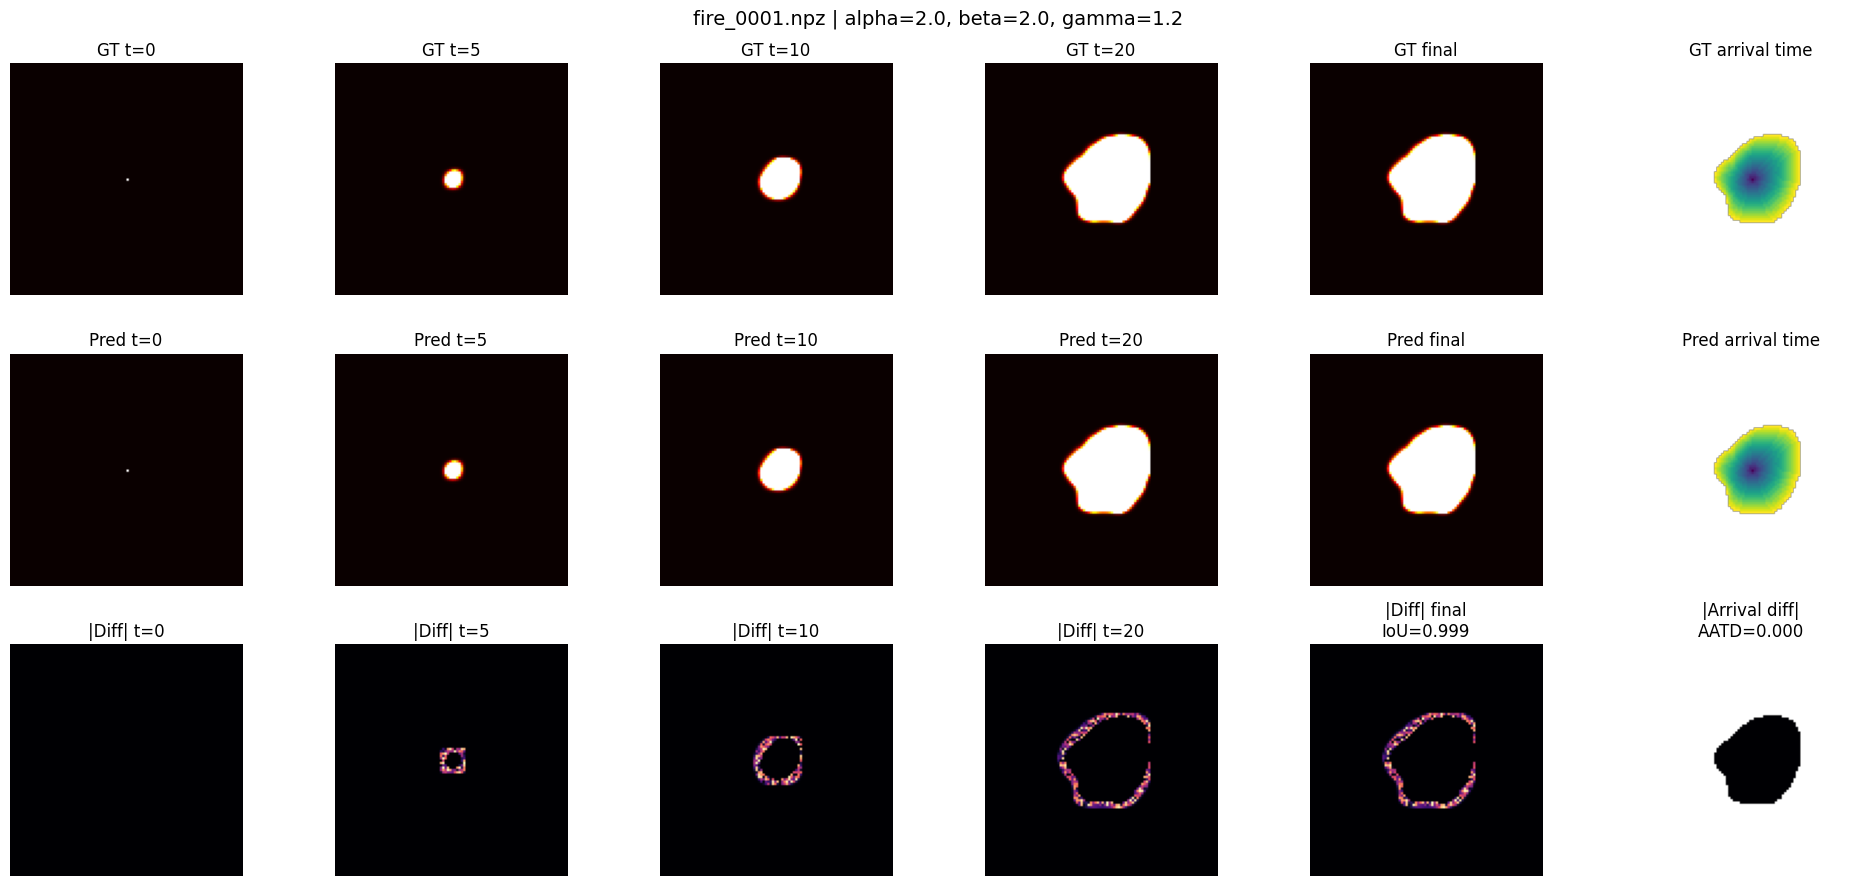

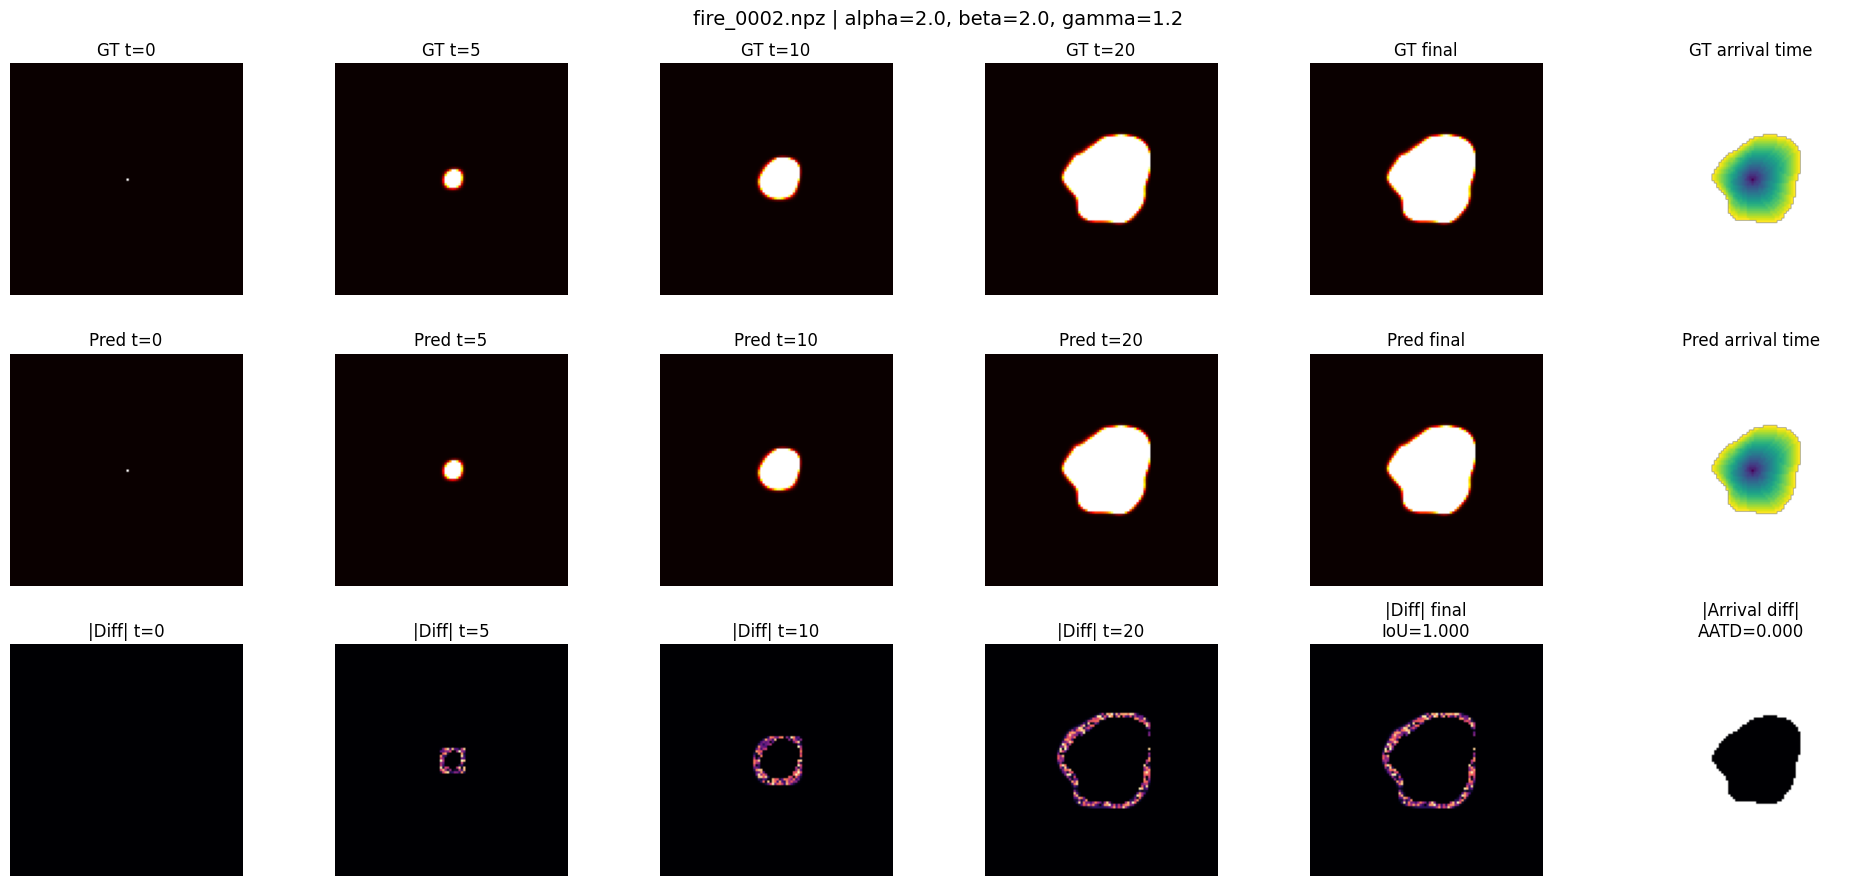

In [25]:
best_alpha, best_beta, best_gamma, best_row = get_best_params(
    results_df,
    criterion="mean_aatd"
)

print("Best parameters according to AATD:")
print(best_row[["alpha", "beta", "gamma", "mean_iou", "mean_aatd"]])

for fire_path in fire_paths[:3]:
    plot_fire_comparison(
        fire_path=fire_path,
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        alpha=best_alpha,
        beta=best_beta,
        gamma=best_gamma,
        n_steps=N_STEPS,
    )